In [1]:
!pip install -q kaggle
!kaggle datasets download -d zalando-research/fashionmnist
!unzip fashionmnist.zip -d fashionmnist/
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import os
import kagglehub
from matplotlib import pyplot as plt

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
100% 68.8M/68.8M [00:04<00:00, 16.3MB/s]

Archive:  fashionmnist.zip
  inflating: fashionmnist/fashion-mnist_test.csv  
  inflating: fashionmnist/fashion-mnist_train.csv  
  inflating: fashionmnist/t10k-images-idx3-ubyte  
  inflating: fashionmnist/t10k-labels-idx1-ubyte  
  inflating: fashionmnist/train-images-idx3-ubyte  
  inflating: fashionmnist/train-labels-idx1-ubyte  


In [2]:
train_df = pd.read_csv('fashionmnist/fashion-mnist_train.csv')
test_df = pd.read_csv('fashionmnist/fashion-mnist_test.csv')

In [3]:
def image_from_row(row, df=train_df):
    return 2*df.iloc[row, 1:].values.reshape(28,28,1)/255 -1

def images_from_df(indices, df=train_df):
    return 2*df.iloc[indices, 1:].values.reshape(len(indices), 28,28,1)/255 -1

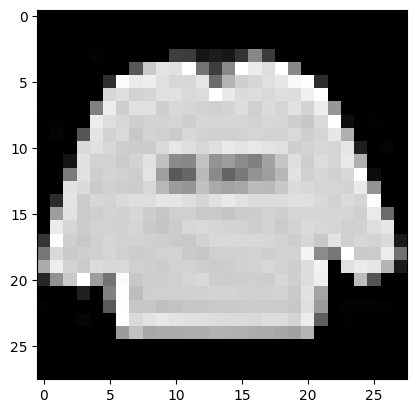

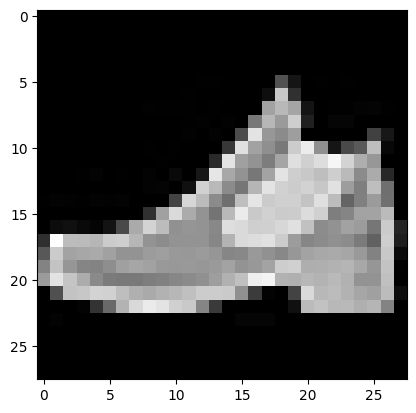

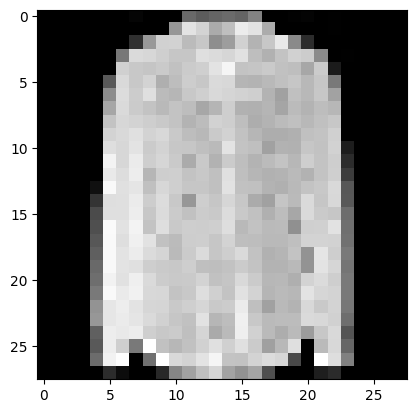

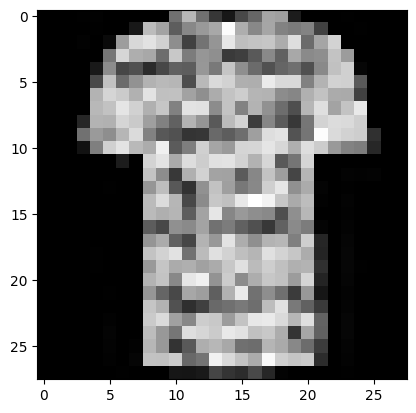

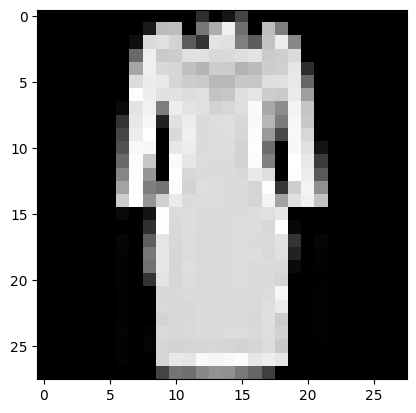

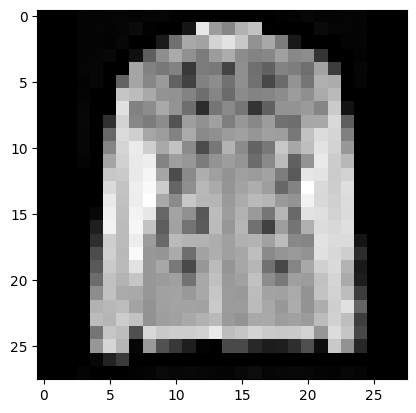

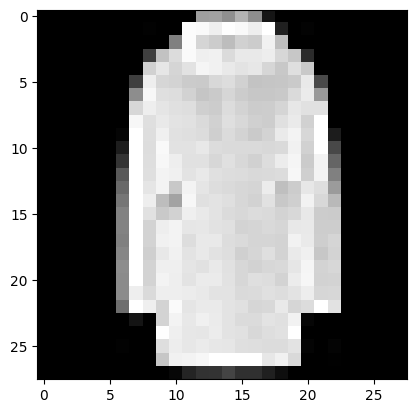

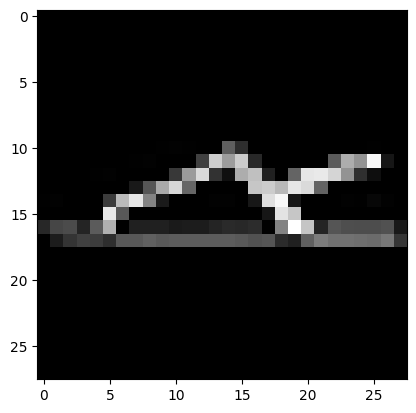

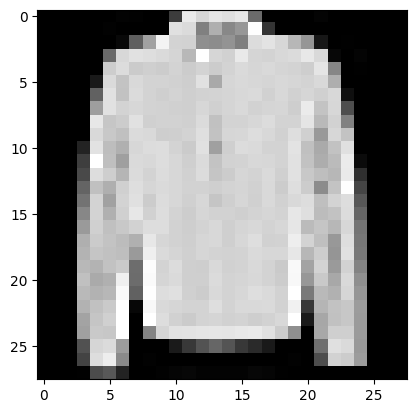

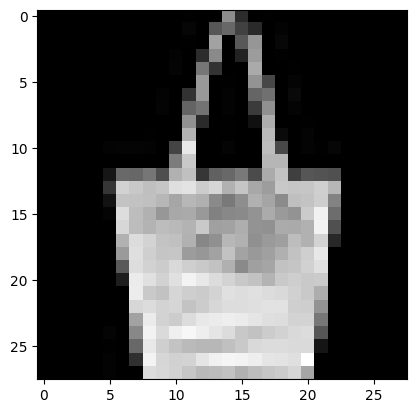

In [4]:
images = images_from_df([0,1,2,3,4,5,6,7,8,9], train_df)
for image_index in range(10):
    plt.figure()
    plt.imshow(images[image_index], cmap="gray")
    plt.show()

In [5]:
from tensorflow.keras import models, layers
critico = models.Sequential()
critico.add(layers.Conv2D(32, (3, 3), activation='leaky_relu', input_shape=(28, 28, 1)))
critico.add(layers.Conv2D(64, (3, 3), activation='leaky_relu'))
critico.add(layers.MaxPooling2D((2, 2)))
critico.add(layers.Conv2D(128, (3, 3), activation='leaky_relu'))
critico.add(layers.MaxPooling2D((2, 2)))
critico.add(layers.Flatten())
critico.add(layers.Dense(256, activation='leaky_relu'))
critico.add(layers.Dense(1))
critico.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,385 (3.48 MB)

 Trainable params: 912,385 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
gerador = models.Sequential()
gerador.add(layers.Conv2DTranspose(64, (5, 5), activation='leaky_relu', padding="same", input_shape=(4, 4, 8)))
gerador.add(layers.BatchNormalization())
gerador.add(layers.Conv2DTranspose(64, (5, 5), activation='leaky_relu', padding="same"))
gerador.add(layers.BatchNormalization())
gerador.add(layers.Conv2DTranspose(32, (5, 5), activation='leaky_relu', padding="same", strides=3))
gerador.add(layers.BatchNormalization())
gerador.add(layers.Conv2DTranspose(16, (6, 6), activation='leaky_relu', strides=2))
gerador.add(layers.BatchNormalization())
gerador.add(layers.Conv2D(1, (3, 3), activation='tanh', padding="same"))
gerador.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (None, 4, 4, 64)       │        12,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 4, 4, 64)       │       102,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 12, 12, 32)     │        51,232 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 16)     │        18,448 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,857 (726.00 KB)

 Trainable params: 185,505 (724.63 KB)

 Non-trainable params: 352 (1.38 KB)

tf.Tensor(0.022294722, shape=(), dtype=float32)


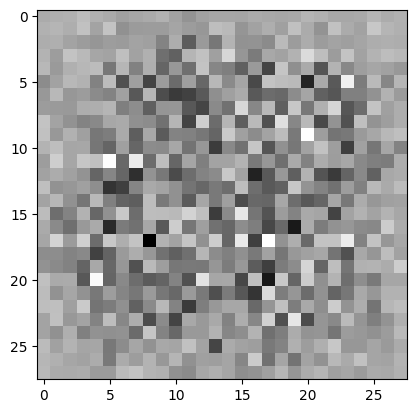

In [7]:
random_vector = tf.random.normal((1,4,4,8))
print(tf.reduce_max(gerador(random_vector)))
plt.imshow(tf.squeeze(gerador(random_vector)[0]), cmap="gray")

In [8]:
import math
from tqdm.notebook import tqdm
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
if not os.path.exists('machine_learning_systems'):
  !git clone https://github.com/LFBJC/machine_learning_systems
if not os.path.exists("checkpoints"):
  !cp -r machine_learning_systems/GAN/checkpoints checkpoints
print(os.listdir("./checkpoints"))


batch_size = 64
epochs = 50
lambda_gp = 10
num_batches = int(math.ceil(train_df.shape[0]/batch_size))


optimizer_gerador = Adam(learning_rate=0.0002, beta_1=0.5)
optimizer_critico = Adam(learning_rate=0.0001, beta_1=0.5)


ckpt = tf.train.Checkpoint(
    gerador=gerador,
    critico=critico,
    optimizer_gerador=optimizer_gerador,
    optimizer_critico=optimizer_critico,
    epoch=tf.Variable(0),
    batch=tf.Variable(0)
)

manager = tf.train.CheckpointManager(
    ckpt,
    "./checkpoints",
    max_to_keep=5
)
print(manager.latest_checkpoint)
ckpt.restore(manager.latest_checkpoint)

initial_epoch = 0
initial_batch = 0
if manager.latest_checkpoint:
    print("Checkpoint carregado!")
    print("Época:", int(ckpt.epoch))
    print("Batch:", int(ckpt.batch))
    initial_epoch =  int(ckpt.epoch.numpy())
    initial_batch = int(ckpt.batch.numpy())
else:
    print("Treinamento do zero.")

loss_history = []
grads_history = {}
for epoch in tqdm(range(initial_epoch, epochs), initial=initial_epoch, total=epochs, desc="epoch"):
    train_df = train_df.sample(frac=1).reset_index(drop=True)
    for batch_index in tqdm(range(initial_batch, num_batches), initial=initial_batch, total=num_batches, desc="batch", leave=False):
        tamanho_batch_atual = min((batch_index+1)*batch_size, train_df.shape[0]) - batch_index*batch_size
        z = tf.random.normal((tamanho_batch_atual,4,4,8))
        with tf.GradientTape(persistent=True) as tape:
            imagens_geradas = gerador(z)
            # print(f"Escala imagens geradas: {tf.reduce_min(imagens_geradas)} -> {tf.reduce_max(imagens_geradas)}")
            imagens_reais = images_from_df(range(batch_index*batch_size, min((batch_index+1)*batch_size, train_df.shape[0])), df=train_df)
            imagens_reais += tf.random.normal(
                imagens_reais.shape,
                stddev=0.05
            )
            imagens_reais = tf.clip_by_value(
                imagens_reais,
                -1.0,
                1.0
            )
            # print(f"Escala imagens reais: {tf.reduce_min(imagens_reais)} -> {tf.reduce_max(imagens_reais)}")
            y_pred_gerado = critico(imagens_geradas)
            y_pred_real = critico(imagens_reais)
            epsilon = tf.random.uniform(
                [tamanho_batch_atual,1,1,1]
            )

            x_hat = (
                epsilon*imagens_reais
                +
                (1-epsilon)*imagens_geradas
            )
            with tf.GradientTape() as gp_tape:
                gp_tape.watch(x_hat)

                pred = critico(x_hat)
            grad = gp_tape.gradient(pred, x_hat)
            norm = tf.sqrt(
                tf.reduce_sum(
                    tf.square(grad),
                    axis=[1,2,3]
                )
            )
            gp = tf.reduce_mean(
                (norm - 1.0) ** 2
            )

            loss_critico = tf.reduce_mean(y_pred_gerado) - tf.reduce_mean(y_pred_real) + lambda_gp*gp
            loss_history.append(loss_critico.numpy())
            loss_gerador = -tf.reduce_mean(y_pred_gerado)
            # gerando mais imagens para treinar o gerador 2 vezes a cada vez que o critico treina para ver se as losses se equilibram
            z = tf.random.normal((tamanho_batch_atual,4,4,8))
            imagens_geradas = gerador(z)
            y_pred_gerado = critico(imagens_geradas)
            loss_gerador = -tf.reduce_mean(y_pred_gerado)

        grads_critico = tape.gradient(loss_critico, critico.trainable_variables)
        optimizer_critico.apply_gradients(
            zip(grads_critico, critico.trainable_variables)
        )
        # if batch_index % 2 == 0:
        grads_gerador = tape.gradient(loss_gerador, gerador.trainable_variables)
        for i, g in enumerate(grads_gerador):
            if g is not None:
                if i in grads_history.keys():
                    grads_history[i].append(tf.reduce_mean(tf.abs(g)).numpy())
                else:
                    grads_history[i] = [tf.reduce_mean(tf.abs(g)).numpy()]
        optimizer_gerador.apply_gradients(
            zip(grads_gerador, gerador.trainable_variables)
        )
        if batch_index % 67 == 0:
          if batch_index == num_batches - 1:
            ckpt.epoch.assign(epoch + 1)
            ckpt.batch.assign(0)
          else:
            ckpt.epoch.assign(epoch)
            ckpt.batch.assign(batch_index + 1)
          save_path = manager.save()
          print("Checkpoint salvo em:", save_path)

Cloning into 'machine_learning_systems'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 60 (delta 0), reused 2 (delta 0), pack-reused 56 (from 1)
Receiving objects: 100% (60/60), 57.25 MiB | 22.79 MiB/s, done.
Resolving deltas: 100% (9/9), done.
['ckpt-4.data-00000-of-00001', 'ckpt-2.data-00000-of-00001', 'ckpt-3.data-00000-of-00001', 'ckpt-1.data-00000-of-00001', 'ckpt-5.data-00000-of-00001', 'ckpt-3.index', 'ckpt-4.index', 'ckpt-2.index', 'ckpt-1.index', 'checkpoint', 'ckpt-5.index']
./checkpoints/ckpt-5
Checkpoint carregado!
Época: 0
Batch: 268


epoch:   0%|          | 0/50 [00:00<?, ?it/s]

batch:  29%|##8       | 268/938 [00:00<?, ?it/s]

Checkpoint salvo em: ./checkpoints/ckpt-6
Checkpoint salvo em: ./checkpoints/ckpt-7
Checkpoint salvo em: ./checkpoints/ckpt-8
Checkpoint salvo em: ./checkpoints/ckpt-9
Checkpoint salvo em: ./checkpoints/ckpt-10
Checkpoint salvo em: ./checkpoints/ckpt-11
Checkpoint salvo em: ./checkpoints/ckpt-12
Checkpoint salvo em: ./checkpoints/ckpt-13
Checkpoint salvo em: ./checkpoints/ckpt-14
Checkpoint salvo em: ./checkpoints/ckpt-15


batch:  29%|##8       | 268/938 [00:00<?, ?it/s]

...

batch:  29%|##8       | 268/938 [00:00<?, ?it/s]

Checkpoint salvo em: ./checkpoints/ckpt-106
Checkpoint salvo em: ./checkpoints/ckpt-107
Checkpoint salvo em: ./checkpoints/ckpt-108
Checkpoint salvo em: ./checkpoints/ckpt-109
Checkpoint salvo em: ./checkpoints/ckpt-110
Checkpoint salvo em: ./checkpoints/ckpt-111
Checkpoint salvo em: ./checkpoints/ckpt-112
Checkpoint salvo em: ./checkpoints/ckpt-113
Checkpoint salvo em: ./checkpoints/ckpt-114
Checkpoint salvo em: ./checkpoints/ckpt-115


batch:  29%|##8       | 268/938 [00:00<?, ?it/s]

Checkpoint salvo em: ./checkpoints/ckpt-116


KeyboardInterrupt: 

**When the training needs to be stopped run the cell bellow to save the checkpoints on the repository**

In [ ]:
!rm -rf machine_learning_systems/checkpoints
!cp -r checkpoints/ machine_learning_systems/checkpoints
!cd machine_learning_systems
!git add checkpoints
!git commit -m "Update checkpoints"

In [ ]:
plt.figure()
plt.suptitle("Gradients")
for indice, valores in grads_history.items():
    plt.plot(valores)
plt.show()
plt.figure()
plt.suptitle("Losses")
plt.plot(loss_history, label='loss')
plt.show()

In [ ]:
z = tf.random.uniform((10,4,4,8))
imagens = gerador(z)
for i in range(10):
    plt.figure()
    plt.imshow(tf.squeeze(imagens[i]), cmap="gray")